In [1]:
###############################################

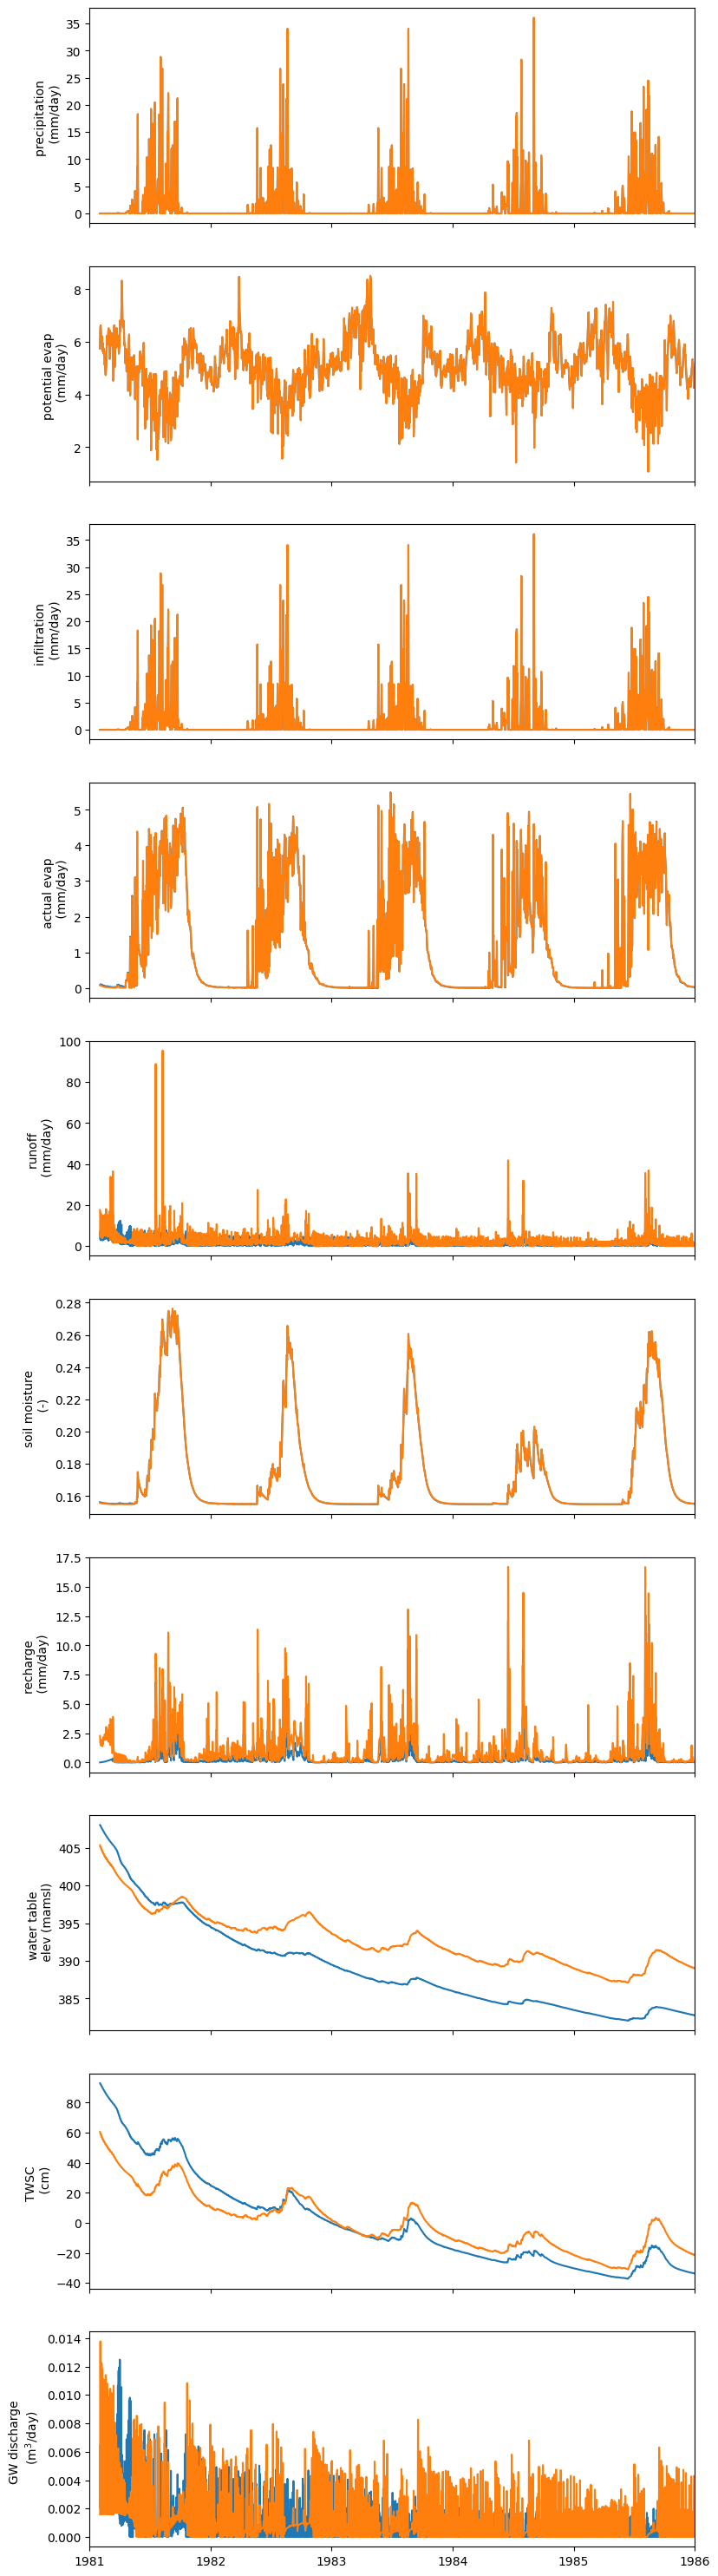

In [5]:
####################################
# comparing two consecutive runs:
path_de = "C:/Users/oshin/OneDrive - Cardiff University/CLARITY/Work_Niger+Nigeria/model/mk_jibiya/outputs/" 
#####

#"""
fsim_dd = [
path_de + "MK_TLab_sim_t1a_avg.csv",
#path_dd + "XXXXXXXXX.csv",
]
#"""
fsim_de = [
path_de + "MK_TLab_sim_t2a_avg.csv"
#path_de + "XXXXXXXXX.csv",
]
#"""
######
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#date_start='2026-02-01', date_end='2055-12-31',
#date_start='1981-02-01', date_end='2023-12-31',
######
def aggregate_slice_csv(fname, agg_step='1D', mean=True,
                        date_start='1981-02-01', date_end='2055-12-31',
                        timefield='Date'):
	df = pd.read_csv(fname)
	df[timefield] = pd.to_datetime(df[timefield])
	df = df[df[timefield].between(date_start, date_end)]
	df.index = pd.DatetimeIndex(df[timefield])
	if mean is True:
		df = df.resample(agg_step).mean()#.reset_index()
	else:
		df = df.resample(agg_step).sum()#.reset_index()
	return df
######
# plot data
###
#fig, ax = plt.subplots(9, 1, sharex=True)
#fig.set_size_inches(9, 25)

fig, ax = plt.subplots(10, 1, sharex=True)
fig.set_size_inches(9, 38)
#"""
label = ['precipitation \n (mm/day)', 'potential evap \n (mm/day)',  'infiltration \n (mm/day)', 'actual evap \n (mm/day)', 'runoff \n (mm/day)', 'soil moisture \n (-)', 'recharge \n (mm/day)', 'water table \n elev (mamsl)', 'TWSC \n (cm)', 'GW discharge \n (m$^3$/day)']#, "twsc"]
field = ['pre_0', 'pet_0', 'inf_0', 'aet_0', 'run_0', 'tht_0', 'rch_0', 'wte_0', 'twsc_0', 'gdh_0']
#ilabel = "sim"
#"""
#"""
########################
for ifname_dd in fsim_dd:
    for ifield, ilabel, iax in zip(field, label, fig.axes):
        data = aggregate_slice_csv(ifname_dd, timefield='Date')
        #ax.plot(data['date'], data['flow(m3/s)'], label=ilabel)#data.plot(y='Flow (Cumecs)')        
        if ifield == "twsc_0":
            #iax.plot(data['Date'], np.cumsum(data[ifield])/10)#, label=ilabel) #np.mean(data[ifield])+0*data[ifield]
            iax.plot(data['Date'], (np.cumsum(data[ifield])-np.mean(np.cumsum(data[ifield])))/10, label='scenario '+ ifname_dd[117:120])
            #iax.plot(data['Date'], data[ifield]-np.mean((data[ifield]))+0*data[ifield], 'k-.')
            #iax.plot(data['Date'], np.mean(np.cumsum(data[ifield]))+0*data[ifield], 'k-.')
            #iax.plot(data['Date'], data[ifield])
        elif ifield == "pre_0":
            iax.plot(data['Date'], data[ifield])#, scale=True)
            #iax.plot(data['Date'], np.mean(data[ifield])+0*data[ifield], 'k--')#, scale=True)
        elif ifield == "pet_0":
            iax.plot(data['Date'], data[ifield])#, scale=True)
            #iax.plot(data['Date'], np.mean(data[ifield])+0*data[ifield], 'k:')#, scale=True)
        elif ifield == "aet_0":
            iax.plot(data['Date'], data[ifield])#, scale=True)
            #iax.plot(data['Date'], np.mean(data[ifield])+0*data[ifield], 'k-.')#, scale=True)
        else:
            iax.plot(data['Date'], data[ifield], label='scenario '+ifname_dd[112:115])#, label=ilabel)  #label=ilabel+'\n scenario'+ifname_de[138:140]
            #iax.plot(data['Date'], np.mean(data[ifield])+0*data[ifield], 'k-.')#, scale=True)
        
        iax.set_ylabel(ilabel)
        iax.grid()
        iax.set_xlim(pd.to_datetime('1981-01-01'), pd.to_datetime('1986-01-01'))
        #iax.set_xlim(pd.to_datetime('2002-01-01'), pd.to_datetime('2024-01-01'))
#"""
#"""
########################
for ifname_de in fsim_de:
    for ifield, ilabel, iax in zip(field, label, fig.axes):
        data = aggregate_slice_csv(ifname_de, timefield='Date')
        #ax.plot(data['date'], data['flow(m3/s)'], label=ilabel)#data.plot(y='Flow (Cumecs)')        
        if ifield == "twsc_0":
            #iax.plot(data['Date'], np.cumsum(data[ifield])/10)#, label=ilabel) #np.mean(data[ifield])+0*data[ifield]
            iax.plot(data['Date'], (np.cumsum(data[ifield])-np.mean(np.cumsum(data[ifield])))/10)
            #iax.plot(data['Date'], data[ifield]-np.mean((data[ifield]))+0*data[ifield], 'k-.')
            #iax.plot(data['Date'], np.mean(np.cumsum(data[ifield]))+0*data[ifield], 'k-.')
            #iax.plot(data['Date'], data[ifield])
        elif ifield == "pre_0":
            iax.plot(data['Date'], data[ifield])#, scale=True)
            #iax.plot(data['Date'], np.mean(data[ifield])+0*data[ifield], 'k--')#, scale=True)
        elif ifield == "pet_0":
            iax.plot(data['Date'], data[ifield])#, scale=True)
            #iax.plot(data['Date'], np.mean(data[ifield])+0*data[ifield], 'k:')#, scale=True)
        elif ifield == "aet_0":
            iax.plot(data['Date'], data[ifield])#, scale=True)
            #iax.plot(data['Date'], np.mean(data[ifield])+0*data[ifield], 'k-.')#, scale=True)
        else:
            iax.plot(data['Date'], data[ifield], label='scenario '+ifname_de[112:115])#, label=ilabel)
            #iax.plot(data['Date'], np.mean(data[ifield])+0*data[ifield], 'k-.')#, scale=True)
        
        iax.set_ylabel(ilabel)
        iax.grid()
        #iax.set_xlim([0, 734])
        ##iax.set_xticks([])
        #iax.set_xlim(pd.to_datetime('1991-01-01'), pd.to_datetime('2024-01-01'))
#"""
#iax.set_xlabel("time/months")
#iax.set_xlim([0, 734])
#####
#plt.grid()